# biocolors — deriving colour from a biosignal

`biotuner.biocolors` turns a signal's spectral peaks — or a tuning's ratios —
into perceptually principled colour palettes. Every colour axis is driven by a
swappable harmonic metric, the working space is perceptually uniform (OKLCh),
and every palette is guaranteed inside the sRGB gamut.

This notebook is a tour of the module on **synthetic signals**, so it runs
anywhere. For the conceptual background and the measured results on real sleep
EEG, see the companion method paper (`docs/biocolors_methods.md`).

The pipeline is: **Signal → Descriptors → Channels → ColorSpec → Render.**

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from biotuner.biocolors import (
    palette_from_signal, palette_from_tuning,
    diversity_report, palette_report, MAPPINGS,
)
from biotuner.biocolors.mapping import TEMPERAMENTS
from biotuner.biocolors import color

def show(palettes, labels, title="", swatch_h=1.0):
    """Draw one or more palettes as rows of swatches."""
    if not isinstance(palettes[0], (list, np.ndarray)) or np.ndim(palettes[0]) == 1:
        palettes = [palettes]; labels = [labels]
    n = len(palettes); w = max(len(p) for p in palettes)
    fig, ax = plt.subplots(figsize=(min(0.9*w, 12), 0.55*n + 0.4))
    for r, (pal, lab) in enumerate(zip(palettes, labels)):
        for i, c in enumerate(pal):
            ax.add_patch(plt.Rectangle((i, n-1-r), 1, swatch_h,
                                       color=np.clip(c, 0, 1), ec="white", lw=1))
        ax.text(-0.15, n-1-r+0.5, lab, ha="right", va="center", fontsize=10)
    ax.set_xlim(0, w); ax.set_ylim(0, n); ax.axis("off")
    if title: ax.set_title(title, loc="left", fontsize=12)
    plt.tight_layout(); plt.show()

C:\Users\skite\Documents\Github\biotuner\.claude\worktrees\epic-morse-ded0d5\biotuner\biotuner_object.py:11: DeprecationWarning: 
The `fooof` package is being deprecated and replaced by the `specparam` (spectral parameterization) package.
This version of `fooof` (1.1) is fully functional, but will not be further updated.
New projects are recommended to update to using `specparam` (see Changelog for details).
  from fooof import FOOOF


## 1. Three entry points

There are three ways in, depending on what you have in hand:

| you have… | call | what it does |
|---|---|---|
| a **raw recording** | `palette_from_raw(data, sf, …)` | runs peak extraction, then maps |
| **peaks + amplitudes** | `palette_from_signal(peaks, amps, …)` | maps a spectrum directly |
| a **tuning** (ratios) | `palette_from_tuning(scale, …)` | maps a scale |

For a real signal, `palette_from_raw` is the front door: you choose the biotuner
**extractor** (`peaks_function`) and **precision**, it recovers the peaks, and it
picks the right amplitude scale automatically. Here we synthesise a short signal
(10 Hz + 20 Hz + 6 Hz in noise) and colour it a few ways.

Adaptive frequency bands:  [[np.float64(2.0), np.float64(3.1)], [np.float64(4.0), np.float64(6.2)], [np.float64(8.1), np.float64(12.4)], [np.float64(16.2), np.float64(24.7)], [np.float64(32.4), np.float64(49.4)]]


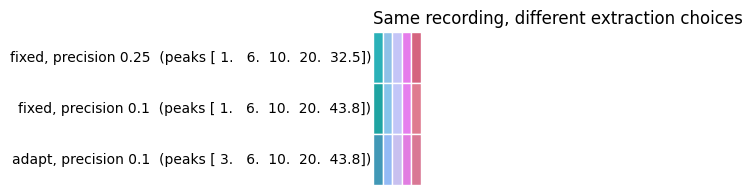

In [2]:
sf = 250
t = np.arange(0, 8, 1/sf)
rng = np.random.default_rng(0)
raw = (1.0*np.sin(2*np.pi*10*t) + 0.6*np.sin(2*np.pi*20*t)
       + 0.8*np.sin(2*np.pi*6*t) + 0.5*rng.standard_normal(len(t)))

from biotuner.biocolors import palette_from_raw
pals, labs = [], []
for pf, prec in [("fixed", 0.25), ("fixed", 0.1), ("adapt", 0.1)]:
    p, bt = palette_from_raw(raw, sf, peaks_function=pf, precision=prec,
                             n_peaks=5, return_bt=True)
    pals.append(p.rgb)
    labs.append(f"{pf}, precision {prec}  (peaks {np.round(np.asarray(bt.peaks, float), 1)})")
show(pals, labs, "Same recording, different extraction choices")

The extractor and precision are genuine choices — a finer precision separates
close peaks, and different `peaks_function` methods see the signal differently
(see the `peaks_extraction` example). `palette_from_raw` records what it used on
`palette.metadata['extraction']`.

For the rest of this notebook we feed **peaks directly** with
`palette_from_signal`, which lets us build controlled synthetic spectra and see
the mapping in isolation — the colours below depend only on the peaks we specify,
not on an extractor.

## 2. A palette from a signal's spectrum

The default `method="anchored"` places the whole palette by a **fingerprint** — an
11-descriptor summary of the spectrum — so signals with different structure land
in different parts of the colour wheel.

C:\Users\skite\AppData\Local\Temp\ipykernel_49740\788983968.py:11: RuntimeWarning: 100% of this signal's descriptors fall outside calibration 'identity' (fit on peaks_function='?', n_peaks=?). Those percentiles are pinned at 0/1, so the hue anchor is largely arbitrary and unrelated signals may share it. Refit with build_calibration() on your own extractor, or pass calibration='none'. See Palette.report()['fingerprint_saturation'].
  p = palette_from_signal(pk, am, calibration="none")
C:\Users\skite\AppData\Local\Temp\ipykernel_49740\788983968.py:11: RuntimeWarning: 100% of this signal's descriptors fall outside calibration 'identity' (fit on peaks_function='?', n_peaks=?). Those percentiles are pinned at 0/1, so the hue anchor is largely arbitrary and unrelated signals may share it. Refit with build_calibration() on your own extractor, or pass calibration='none'. See Palette.report()['fingerprint_saturation'].
  p = palette_from_signal(pk, am, calibration="none")
C:\Users\skite\AppData

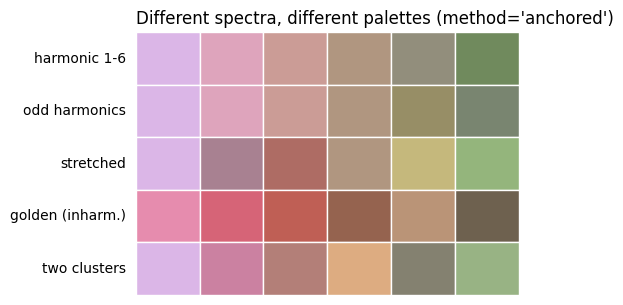

In [3]:
PHI = (1 + 5**0.5) / 2
signals = {
    "harmonic 1-6":    (np.array([100., 200, 300, 400, 500, 600]), np.ones(6)),
    "odd harmonics":   (np.array([100., 300, 500, 700, 900, 1100]), np.ones(6)),
    "stretched":       (np.array([100., 205, 315, 430, 550, 675]), np.ones(6)),
    "golden (inharm.)":(np.array([100.*PHI**k for k in range(6)]), np.ones(6)),
    "two clusters":    (np.array([100., 104, 108, 400, 415, 430]), np.ones(6)),
}
pals, labs = [], []
for name, (pk, am) in signals.items():
    p = palette_from_signal(pk, am, calibration="none")
    pals.append(p.rgb); labs.append(name)
show(pals, labs, "Different spectra, different palettes (method='anchored')")

The palettes are visibly distinct because the anchor is a *direction* in an
11-dimensional descriptor space, not a single scalar. We can quantify that
diversity — `diversity_report` measures the mean pairwise perceptual distance
(ΔE in OKLab) between palettes.

In [4]:
pal_objs = [palette_from_signal(pk, am, calibration="none")
            for pk, am in signals.values()]
rep = diversity_report(pal_objs)
print(f"mean pairwise palette ΔE : {rep['mean_palette_deltaE']:.3f}")
print(f"min  pairwise palette ΔE : {rep['min_palette_deltaE']:.3f}")
print(f"hue-wheel occupancy      : {rep['hue_occupancy']*100:.0f}%")

mean pairwise palette ΔE : 0.093
min  pairwise palette ΔE : 0.011
hue-wheel occupancy      : 6%


C:\Users\skite\AppData\Local\Temp\ipykernel_49740\2790120548.py:1: RuntimeWarning: 100% of this signal's descriptors fall outside calibration 'identity' (fit on peaks_function='?', n_peaks=?). Those percentiles are pinned at 0/1, so the hue anchor is largely arbitrary and unrelated signals may share it. Refit with build_calibration() on your own extractor, or pass calibration='none'. See Palette.report()['fingerprint_saturation'].
  pal_objs = [palette_from_signal(pk, am, calibration="none")
C:\Users\skite\AppData\Local\Temp\ipykernel_49740\2790120548.py:1: RuntimeWarning: 100% of this signal's descriptors fall outside calibration 'identity' (fit on peaks_function='?', n_peaks=?). Those percentiles are pinned at 0/1, so the hue anchor is largely arbitrary and unrelated signals may share it. Refit with build_calibration() on your own extractor, or pass calibration='none'. See Palette.report()['fingerprint_saturation'].
  pal_objs = [palette_from_signal(pk, am, calibration="none")
C:\Use

## 3. Six ways to derive colour

The module registers eight mapping **methods** across six families. They differ
in *what hue means*:

| family | method(s) | hue encodes |
|---|---|---|
| physical | `spectral` | the peak's folded wavelength (a real colour) |
| relational | `mds` | position in a consonance-similarity embedding |
| statistical | `anchored` | a direction in the calibrated fingerprint |
| declarative | `tonotopic`, `consonance`, `harmonic`, `tenney` | a **named** quantity |
| learned | `derived` | the data's own principal components |

The physical and statistical methods separate signals well; the declarative
colourspaces are *readable* — the hue means a stated quantity — at the cost of
separation.

C:\Users\skite\AppData\Local\Temp\ipykernel_49740\460304300.py:7: RuntimeWarning: 73% of this signal's descriptors fall outside calibration 'identity' (fit on peaks_function='?', n_peaks=?). Those percentiles are pinned at 0/1, so the hue anchor is largely arbitrary and unrelated signals may share it. Refit with build_calibration() on your own extractor, or pass calibration='none'. See Palette.report()['fingerprint_saturation'].
  p = palette_from_signal(pk, am, method=m, calibration="none")


C:\Users\skite\AppData\Local\Temp\ipykernel_49740\460304300.py:7: RuntimeWarning: 73% of this signal's descriptors fall outside calibration 'identity' (fit on peaks_function='?', n_peaks=?). Those percentiles are pinned at 0/1, so the hue anchor is largely arbitrary and unrelated signals may share it. Refit with build_calibration() on your own extractor, or pass calibration='none'. See Palette.report()['fingerprint_saturation'].
  p = palette_from_signal(pk, am, method=m, calibration="none")
C:\Users\skite\AppData\Local\Temp\ipykernel_49740\460304300.py:7: RuntimeWarning: 73% of this signal's descriptors fall outside calibration 'identity' (fit on peaks_function='?', n_peaks=?). Those percentiles are pinned at 0/1, so the hue anchor is largely arbitrary and unrelated signals may share it. Refit with build_calibration() on your own extractor, or pass calibration='none'. See Palette.report()['fingerprint_saturation'].
  p = palette_from_signal(pk, am, method=m, calibration="none")
C:\Use

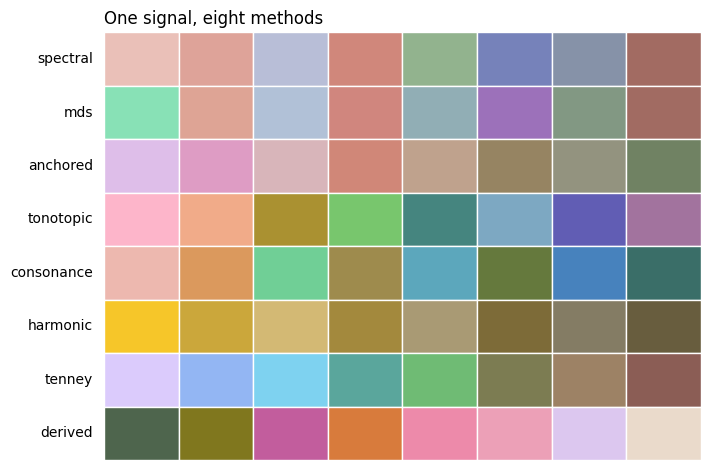

In [5]:
pk = np.array([100., 200, 300, 400, 500, 600, 700, 800.])
am = np.array([1.0, 0.8, 0.9, 0.5, 0.6, 0.3, 0.4, 0.2])
methods = ["spectral", "mds", "anchored", "tonotopic", "consonance",
           "harmonic", "tenney", "derived"]
pals, labs = [], []
for m in methods:
    p = palette_from_signal(pk, am, method=m, calibration="none")
    pals.append(p.rgb); labs.append(m)
show(pals, labs, "One signal, eight methods")

### Declarative colourspaces are interpretable

In the `consonance` colourspace, **hue *is* consonance**: it moves
monotonically as the consonance of each step changes, so you can read the
quantity back off the colour. This is the payoff of naming the axis.

In [6]:
from biotuner.biocolors.descriptors import make_context, compute
ctx = make_context(pk, am, amps_scale="linear")
p = palette_from_signal(pk, am, method="consonance", calibration="none")
cons = np.asarray(compute("consonance", ctx), float)
order = np.argsort(cons)
print("consonance (sorted):", np.round(cons[order], 1))
print("hue at those steps :", np.round(p.spec.h[order], 0))

consonance (sorted): [40.1 42.7 55.8 56.  59.8 61.5 73.  87.5]
hue at those steps : [250. 219. 187. 156. 124.  93.  61.  30.]


C:\Users\skite\AppData\Local\Temp\ipykernel_49740\3561334605.py:3: RuntimeWarning: 73% of this signal's descriptors fall outside calibration 'identity' (fit on peaks_function='?', n_peaks=?). Those percentiles are pinned at 0/1, so the hue anchor is largely arbitrary and unrelated signals may share it. Refit with build_calibration() on your own extractor, or pass calibration='none'. See Palette.report()['fingerprint_saturation'].
  p = palette_from_signal(pk, am, method="consonance", calibration="none")


## 4. Temperament — the character of a palette

`temperament` sets *where* a palette sits in a (lightness × chroma × hue-arc)
plane. `auto` (the default) lets the signal choose a coherent single-temperature
family; the named presets are fixed points; `aurora` deliberately spans warm
through cool in one palette.

C:\Users\skite\AppData\Local\Temp\ipykernel_49740\3405746525.py:5: RuntimeWarning: 73% of this signal's descriptors fall outside calibration 'identity' (fit on peaks_function='?', n_peaks=?). Those percentiles are pinned at 0/1, so the hue anchor is largely arbitrary and unrelated signals may share it. Refit with build_calibration() on your own extractor, or pass calibration='none'. See Palette.report()['fingerprint_saturation'].
  p = palette_from_signal(pk, am, temperament=t, calibration="none")
C:\Users\skite\AppData\Local\Temp\ipykernel_49740\3405746525.py:5: RuntimeWarning: 73% of this signal's descriptors fall outside calibration 'identity' (fit on peaks_function='?', n_peaks=?). Those percentiles are pinned at 0/1, so the hue anchor is largely arbitrary and unrelated signals may share it. Refit with build_calibration() on your own extractor, or pass calibration='none'. See Palette.report()['fingerprint_saturation'].
  p = palette_from_signal(pk, am, temperament=t, calibration="n

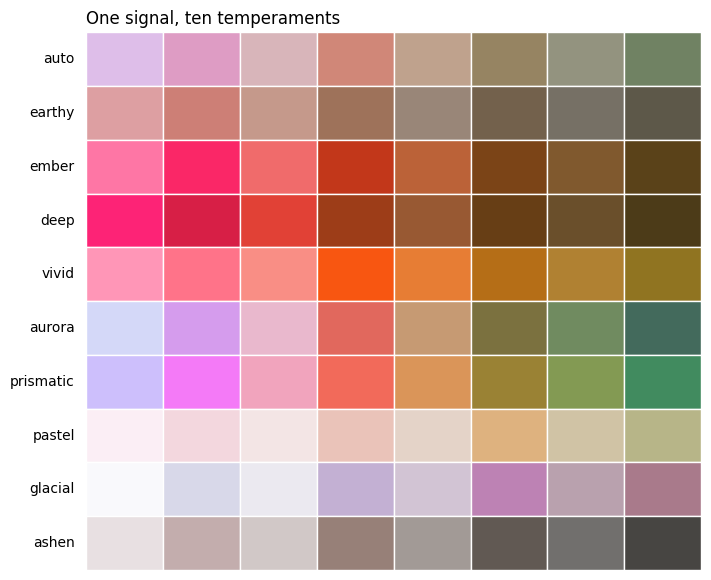

In [7]:
names = ["auto", "earthy", "ember", "deep", "vivid",
         "aurora", "prismatic", "pastel", "glacial", "ashen"]
pals, labs = [], []
for t in names:
    p = palette_from_signal(pk, am, temperament=t, calibration="none")
    pals.append(p.rgb); labs.append(t)
show(pals, labs, "One signal, ten temperaments")

## 5. Colouring a tuning

A *tuning* is a set of frequency ratios rather than a spectrum. `palette_from_tuning`
routes it through the tuning-appropriate calibration. Since a tuning has no
amplitudes, lightness is driven by a ratio-intrinsic metric (ratio simplicity)
instead of loudness.

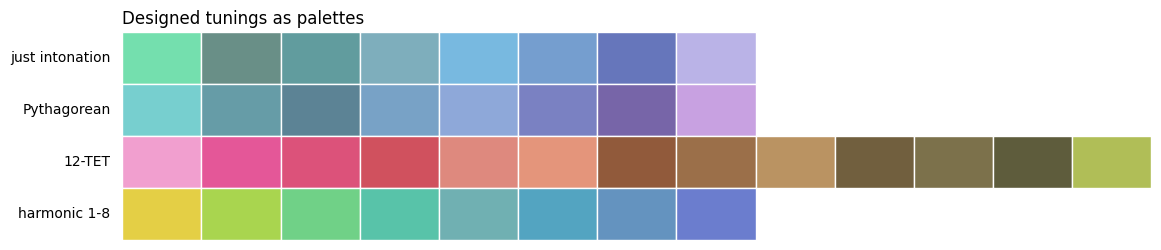

In [8]:
tunings = {
    "just intonation": np.array([1, 9/8, 5/4, 4/3, 3/2, 5/3, 15/8, 2.]),
    "Pythagorean":     np.array([1, 9/8, 81/64, 4/3, 3/2, 27/16, 243/128, 2.]),
    "12-TET":          np.array([2**(i/12) for i in range(13)]),
    "harmonic 1-8":    np.arange(1, 9.),
}
pals, labs = [], []
for name, sc in tunings.items():
    p = palette_from_tuning(sc)
    pals.append(p.rgb); labs.append(name)
show(pals, labs, "Designed tunings as palettes")

### Two ways to colour a recording: its spectrum, or a tuning

Some colour methods read the **spectrum** (peaks + amplitudes) — `anchored`,
`spectral`, `mds`, and the declarative colourspaces. Others read a **tuning**
(ratios). `palette_from_raw` reaches both from the same signal: pass a spectrum
`level` for the first, or a `tuning` source for the second.

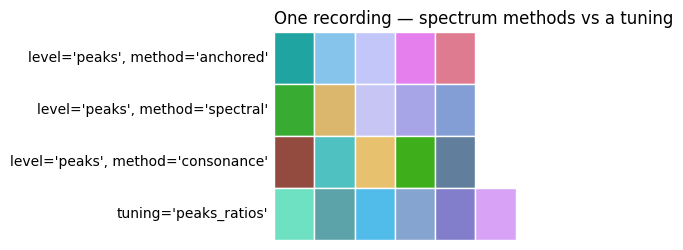

In [9]:
# (a) spectrum methods, from the peaks
pals, labs = [], []
for m in ["anchored", "spectral", "consonance"]:
    p = palette_from_raw(raw, sf, level="peaks", method=m)
    pals.append(p.rgb); labs.append(f"level='peaks', method='{m}'")
# (b) the same recording coloured as a tuning
p = palette_from_raw(raw, sf, tuning="peaks_ratios")
pals.append(p.rgb); labs.append("tuning='peaks_ratios'")
show(pals, labs, "One recording — spectrum methods vs a tuning")

### A tuning from a raw signal — two independent choices

Deriving a *tuning* from a recording involves **two** decisions, and both change
the scale:

1. the **extractor** (`peaks_function`) — *which* peaks you get from the signal;
2. the **derivation** (`source`) — *how* those peaks become a scale.

The derivation itself lives in the tuning layer — `tuning_from_raw` (from
`biotuner.biotuner_object`) returns the ratios, for export or sonification;
`palette_from_raw(..., tuning=…)` colours them.

**First axis — same derivation (`peaks_ratios`), different extractors.** Each
`peaks_function` sees the signal differently (fixed bands, adaptive bands,
cepstral quefrency, empirical-mode decomposition), so each yields a different
tuning from the same recording.

Adaptive frequency bands:  [[np.float64(2.0), np.float64(3.1)], [np.float64(4.0), np.float64(6.2)], [np.float64(8.1), np.float64(12.4)], [np.float64(16.2), np.float64(24.7)], [np.float64(32.4), np.float64(49.4)]]
Adaptive frequency bands:  [[np.float64(2.0), np.float64(3.1)], [np.float64(4.0), np.float64(6.2)], [np.float64(8.1), np.float64(12.4)], [np.float64(16.2), np.float64(24.7)], [np.float64(32.4), np.float64(49.4)]]


C:\Users\skite\AppData\Local\Programs\Python\Python310\lib\site-packages\scipy\signal\_peak_finding.py:266: ComplexWarning: Casting complex values to real discards the imaginary part
  value = np.asarray(value, order='C', dtype=np.float64)
C:\Users\skite\AppData\Local\Programs\Python\Python310\lib\site-packages\scipy\signal\_peak_finding.py:266: ComplexWarning: Casting complex values to real discards the imaginary part
  value = np.asarray(value, order='C', dtype=np.float64)


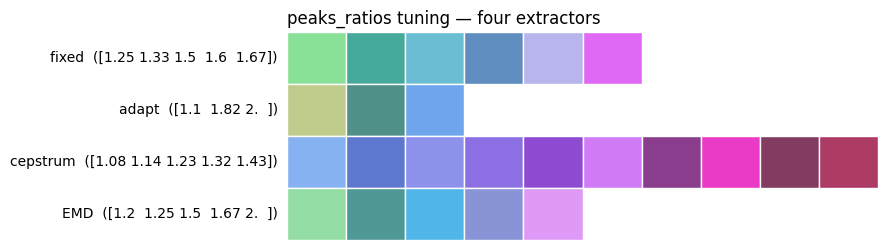

In [10]:
from biotuner.biotuner_object import tuning_from_raw, TUNING_SOURCES
pals, labs = [], []
for pf in ["fixed", "adapt", "cepstrum", "EMD"]:
    scale = tuning_from_raw(raw, sf, source="peaks_ratios",
                            peaks_function=pf, precision=0.5)
    p = palette_from_raw(raw, sf, tuning="peaks_ratios",
                         peaks_function=pf, precision=0.5)
    pals.append(p.rgb)
    labs.append(f"{pf}  ({np.round(np.sort(scale)[:5], 2)})")
show(pals, labs, "peaks_ratios tuning — four extractors")

**Second axis — same extractor (`fixed`), different derivations.** From one
set of peaks, biotuner builds a scale several ways: the ratios of the peaks, the
minima of the **dissonance curve** (a critical-band, timbre-dependent scale),
harmonic entropy, a harmonic-fit tuning.

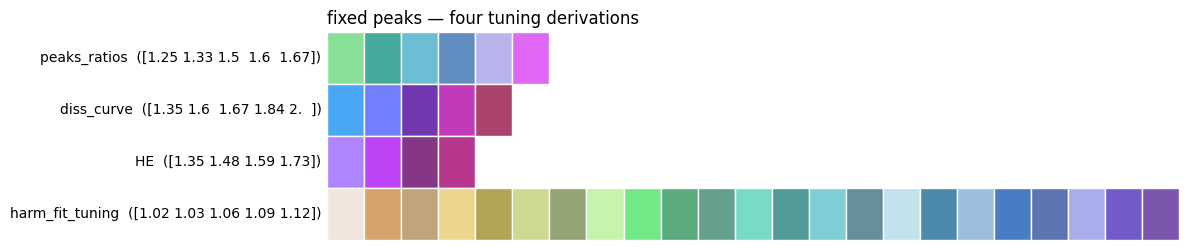

In [11]:
pals, labs = [], []
for src in ["peaks_ratios", "diss_curve", "HE", "harm_fit_tuning"]:
    scale = tuning_from_raw(raw, sf, source=src, precision=0.5)
    p = palette_from_raw(raw, sf, tuning=src, precision=0.5)
    pals.append(p.rgb)
    labs.append(f"{src}  ({np.round(np.sort(scale)[:5], 2)})")
show(pals, labs, "fixed peaks — four tuning derivations")

## 6. The colour layer

Underneath the mappings is a dependency-free perceptual colour layer. Two ideas
make it faithful. First, **chroma is requested relative to the local gamut
ceiling** (the *cusp*), which varies several-fold around the hue wheel — so a
fixed chroma is impossible to get right everywhere.

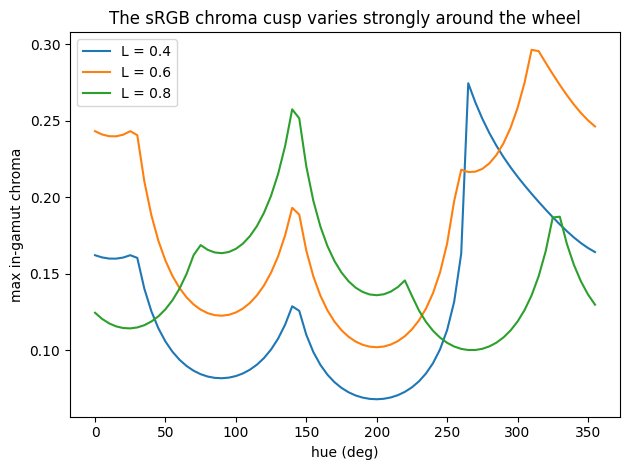

In [12]:
hues = np.arange(0, 360, 5.)
for L in (0.4, 0.6, 0.8):
    ceil = [color.max_chroma(L, h) for h in hues]
    plt.plot(hues, ceil, label=f"L = {L}")
plt.xlabel("hue (deg)"); plt.ylabel("max in-gamut chroma")
plt.title("The sRGB chroma cusp varies strongly around the wheel")
plt.legend(); plt.tight_layout(); plt.show()

Second, the spectral locus (wavelength → colour) uses the **CIE 1931**
colour-matching functions by default, which keep hue resolution across the whole
visible band, rather than an approximation that flattens the red end.

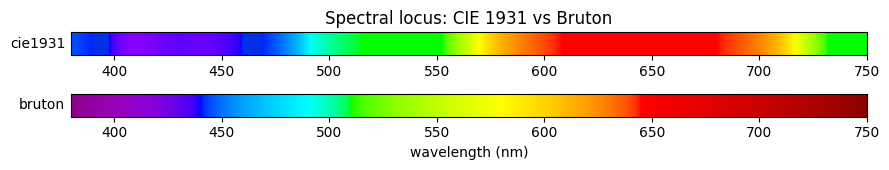

In [13]:
nm = np.linspace(380, 750, 400)
fig, axes = plt.subplots(2, 1, figsize=(9, 1.8))
for ax, method in zip(axes, ["cie1931", "bruton"]):
    rgb = color.wavelength_to_srgb(nm, method=method)
    ax.imshow(np.clip(rgb, 0, 1)[None, :, :], aspect="auto",
              extent=[380, 750, 0, 1])
    ax.set_yticks([]); ax.set_ylabel(method, rotation=0, ha="right", va="center")
axes[1].set_xlabel("wavelength (nm)")
axes[0].set_title("Spectral locus: CIE 1931 vs Bruton")
plt.tight_layout(); plt.show()

## 7. Auditing a palette

Because the working space is perceptually uniform, "these colours are
distinguishable" becomes a *measured* claim. `palette_report` returns the
minimum perceptual distance between swatches, the same under simulated
colour-vision deficiency, and a gamut check.

In [14]:
p = palette_from_signal(pk, am, calibration="none")
r = p.report()
print("hex             :", p.hex())
print("min ΔE (all)    :", round(r["min_deltaE"], 3))
print("min ΔE adjacent :", round(r["min_adjacent_deltaE"], 3))
print("min ΔE under CVD:", {k: round(v, 3) for k, v in r["min_deltaE_cvd"].items()})
print("all in gamut    :", r["gamut"]["frac_out_of_gamut"] == 0.0)

hex             : ['#debee9', '#de9cc4', '#d8b5ba', '#d08778', '#bfa28d', '#968462', '#93937f', '#708263']
min ΔE (all)    : 0.048
min ΔE adjacent : 0.048
min ΔE under CVD: {'protan': 0.01, 'deutan': 0.038, 'tritan': 0.041, 'worst': 0.01}
all in gamut    : True


C:\Users\skite\AppData\Local\Temp\ipykernel_49740\695277729.py:1: RuntimeWarning: 73% of this signal's descriptors fall outside calibration 'identity' (fit on peaks_function='?', n_peaks=?). Those percentiles are pinned at 0/1, so the hue anchor is largely arbitrary and unrelated signals may share it. Refit with build_calibration() on your own extractor, or pass calibration='none'. See Palette.report()['fingerprint_saturation'].
  p = palette_from_signal(pk, am, calibration="none")


Every swatch can also explain itself — which descriptor drove each of its
lightness, chroma, and hue.

In [15]:
print(p.explain(2))

step 2  ratio=3.0000  freq=300.00 Hz  ->  #d8b5ba
  anchor  = 45.0deg  <- fingerprint (radius=0.500, PCA covers 100% of corpus var)
  hue     =    7.50deg <- pitch, t=0.29, arc=175deg
  light   =  0.8051   <- amplitude, t=0.86 -> Lr=0.773
  chroma  =  0.0417   <- consonance, t=0.43 -> 36% of cusp (0.115)
  style   = auto   calibration = identity


---

**See also**
- `docs/biocolors_methods.md` — the method paper (conceptual + measured results).
- `docs/biocolors_architecture.md` — the architecture and design notes.